Computing a global dendrogram by merging local, vertically split dendrograms
============================================================================

Since the dendrogram is a very global operation and it can be difficult to merge horizontally split dendrograms, we try vertical splitting as suggested by @LarsvE568.

Let's start by doing some imports and defining the data

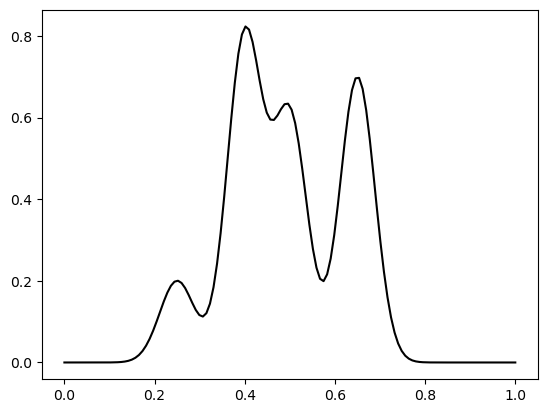

In [1]:
import heat as ht
import numpy as np
import matplotlib.pyplot as plt
from dendro.utils import get_1d_data
from astrodendro.dendrogram import Dendrogram

x, data = get_1d_data(128)
plt.plot(x.larray, data.larray, color='black')

Next, we define the vertical split.
To this end, we need to sort the data and then get local data by applying a slice on the sorted indices.
We include a halo, so that we can later tell more easily how to merge structures from adjacent dendrograms

In [2]:
ntasks = 3
elements_per_task = int(np.ceil(data.shape[0] / ntasks))
halo_size = 2

In [3]:
local_slices = [slice(i*elements_per_task, (i+1)*elements_per_task) for i in range(ntasks)]
for i in range(ntasks):
    start = i * elements_per_task
    stop = start + elements_per_task
    if i > 0:
        start -= halo_size
    if i < ntasks - 1:
        stop += halo_size
    local_slices[i] = slice(start, stop)

In [4]:
idx = np.argsort(data.numpy())
local_idx = [sorted(idx[s]) for s in local_slices]  # we need to sort the indices to express adjacency for the subsequent dendrogram computation

Let's see the data on each task

plt.plot(x.larray, data.larray, color='black')
for i in range(ntasks):
    marker = 'o' if i % 2 == 0 else 'x'
    plt.scatter(x[local_idx[i]], data[local_idx[i]], marker=marker, label=f'Data on task {i}')
plt.legend(frameon=False)

Next, we simply compute dendrograms on the local data.

In [5]:
local_dendrograms = [Dendrogram.compute(np.array(data.larray)[_idx]) for _idx in local_idx]

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_53546/3824651661.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  local_dendrograms = [Dendrogram.compute(np.array(data.larray)[_idx]) for _idx in local_idx]


Before we continue, we have to map the local indices in the local dendrograms to global indices

In [6]:
def local_to_global_index(_local_idx, leaves):
    for leaf in leaves:
        leaf._indices = [_local_idx[i[0]] for i in leaf._indices]
        local_to_global_index(_local_idx=_local_idx, leaves=leaf._children)

for i in range(ntasks):
    local_to_global_index(local_idx[i], local_dendrograms[i].trunk)

Let's plot the local dendrograms

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_53546/1242058446.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax.scatter(np.array(x)[leaf._indices], np.array(data)[leaf._indices], marker=markers[level])


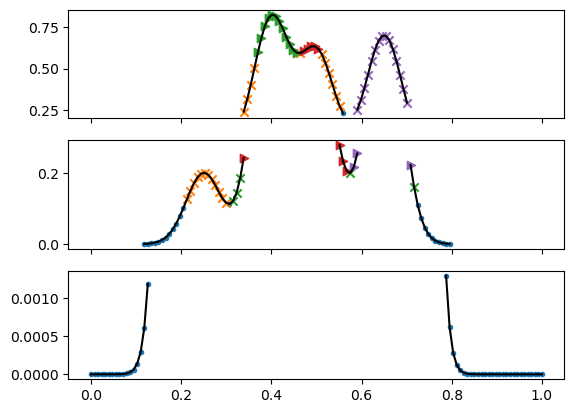

In [7]:
def plot_astrodendro_leaves(ax, leaves, level=0):
    markers = {0: ".", 1: "x", 2: ">", 3: "o", 4: "<"}
    for leaf in leaves:
        ax.scatter(np.array(x)[leaf._indices], np.array(data)[leaf._indices], marker=markers[level])
        plot_astrodendro_leaves(ax=ax, leaves=leaf._children, level=level + 1)

fig, axs = plt.subplots(ntasks, 1, sharex=True)
for i in range(ntasks):
    ax = axs[-i-1] if ntasks > 1 else axs
    _data = data.copy()
    _data[...] = np.nan
    _data[local_idx[i]] = data[local_idx[i]]
    ax.plot(x.larray, _data.larray, color='black')

    plot_astrodendro_leaves(ax, local_dendrograms[i].trunk)

Ok great! Let's have a look at the global dendrogram that we want to recover

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_53546/2095812959.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  global_dendrogram = Dendrogram.compute(np.array(data))
/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_53546/1242058446.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax.scatter(np.array(x)[leaf._indices], np.array(data)[leaf._indices], marker=markers[level])


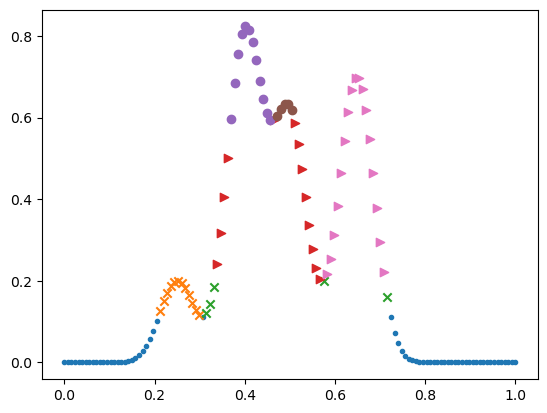

In [8]:
global_dendrogram = Dendrogram.compute(np.array(data))

fig, ax = plt.subplots()
plot_astrodendro_leaves(ax, global_dendrogram.trunk)

Alright, now let's figure out how to merge these local dendrograms with the correct tree structure!

In [9]:
merged_dendrogram = local_dendrograms[0]

def attach_to_structure(attach_to, structure):
    intersection = np.intersect1d(attach_to._indices, structure._indices)
    if len(intersection) > 0:
        assert len(attach_to.children) == 0
        attach_to.children = structure.children
        attach_to._indices = list(np.unique(np.append(attach_to._indices, structure._indices)))
    else:
        for child in attach_to.children:
            attach_to_structure(child, structure)

for i in range(1, ntasks):
    to_merge = local_dendrograms[i]
    attach_to_structure(merged_dendrogram.trunk[0], to_merge.trunk[0])

Let's see our merged dendrogram

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_53546/1242058446.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax.scatter(np.array(x)[leaf._indices], np.array(data)[leaf._indices], marker=markers[level])


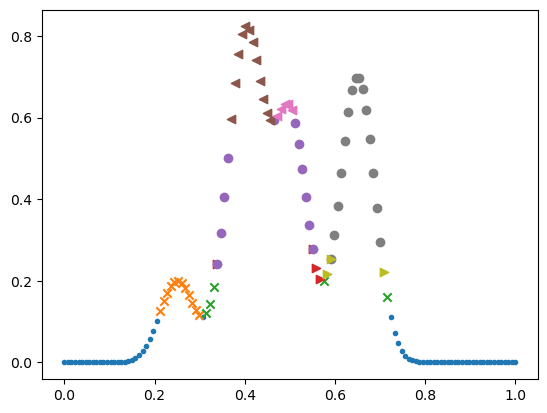

In [10]:
fig, ax = plt.subplots()
plot_astrodendro_leaves(ax, merged_dendrogram.trunk)

In [11]:
if __name__ == '__main__':
    plt.show()